> # **Proyecto #2: Fibra Óptica GRIN (GRaded INdex Fiber) - Thomas A. Hernández**


In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

El presente código busca mostrar la forma de las gráficas que se obtienen de estudiar diferentes condiciones iniciales de un sistema de una fibra óptica GRIN, donde el índice de refracción se modela de la forma:

$$n(\vec{r}) = \sqrt{n_{0}^2 - \frac{x^2 + y^2}{R_{0}^{2}}}$$

Las soluciones detalladas para este sistema se encuentran en el material suplementario (Solución_Escrita.pdf), aquí sólo se trazarán los perfiles transversales, la forma en el diagrama de fase y la trayectoria en 3D. Los perfiles radiales son fáciles de modelar dada la solución:

$$\vec{r}(z) = \vec{r}_{0}\cos(\omega{z}) + \frac{\vec{p}_{0}}{\gamma\omega}\sin(\omega{z})$$
$$\vec{p}(z) = \vec{p}_{0}\cos(\omega{z}) - \omega\gamma\vec{r}_{0}\sin(\omega{z})$$

para $\gamma$ una constante de movimiento igual a $-H(x, y, p_{x}, p_{y}, z)$. La frecuencia de oscilación espacial es igual a:

$$\omega = \frac{k_{0}}{\gamma{R}_{0}}$$

> # **Adimensionalización del problema:**




En el problema tenemos un total de 3 cantidades con unidades: $n_0, R_0$ y $k_0$. Para adimensionalizar el problema, consideremos el Hamiltoniano del sistema:

$$H(x, y, p_x, p_y) = -\sqrt{(k_{0}n(r))^{2} - p_{x}^{2} - p_{y}^{2}} = k_{0}n_{0}\sqrt{1 - \frac{\rho^{2}}{(k_{0}n_{0}R_{0})^{2}} - \frac{p_{x}^{2}}{(k_{0}n_{0})^{2}} - \frac{p_{y}^{2}}{(k_{0}n_{0})^{2}}}$$

Redefiniendo nuevas variables tilda adimensionales quedaría:

$$\tilde{H}(\tilde{x}, \tilde{y}, p_{\tilde{x}}, p_{\tilde{y}})= -\sqrt{1 - \tilde{\rho}^{2} - \tilde{p}_x^{2} - \tilde{p}_y^{2}} = -\frac{\gamma}{k_{0}n_{0}} = -\tilde{\gamma}$$

Para el momento angular $L_{z}$ la adimensionalización es:

$$\tilde{L}_{z} = \frac{L_{z}}{k_{0}n_{0}R_{0}},$$

la cual sale de considerar que $[L_{z}] = [r]\times[p] = R_{0} \times k_{0}R_{0}$. Por último, las posiciones en $x$ y $y$ se adimensionalizan considerando la el radio esencial de la fibra $R_{0}$:

$$\tilde{x} = \frac{x}{R_{0}} \qquad \text{y} \qquad \tilde{y} = \frac{y}{R_{0}}$$

Por último, para que el producto $\omega{z}$ sea adimensional, se requiere que:

$$\tilde{\omega} = \omega \cdot n_{0}R_{0} = \frac{k_{0}}{\gamma{R_{0}}} \cdot n_{0}R_{0} = \frac{1}{\tilde{\gamma}} \qquad \tilde{z} = \frac{z}{n_{0}R_{0}}$$

In [2]:
k0, n0, R0 = 1.0, 1.0, 1.0 # Variables de la adimensionalización del problema.

def ConstantesMovimiento(x0, y0, px0, py0):
    """
    Esta función realiza el cálculo de las constantes de movimiento *gamma* y *Lz*,
    donde la primera es un análogo de la energía del sistema, mientras que Lz es 
    la componente del momento angular a lo largo del eje óptico.
    """
    gamma = np.sqrt(1 - (x0**2 + y0**2 + px0**2 + py0**2))
    Lz = x0*py0 - y0*px0
    return gamma, Lz

def Trayectorias(x0, y0, px0, py0, zt = 1000, zTs = 2):
    """
    Esta función me ayuda a recuperar la información necesaria para graficar las trayectorias
    del sistema.
        - zt -> Número de pasos z-temporales.
        - zTs -> Número de z-periodos.
    """
    gamma, Lz = ConstantesMovimiento(x0, y0, px0, py0)
    omega = 1/gamma
    periodo = 2*np.pi/omega

    z = np.linspace(0, periodo*zTs, zt)

    x = x0*np.cos(omega*z) + (px0/(gamma*omega))*np.sin(omega*z)
    y = y0*np.cos(omega*z) + (py0/(gamma*omega))*np.sin(omega*z)
    px = px0*np.cos(omega*z) - (x0*gamma*omega)*np.sin(omega*z)
    py = py0*np.cos(omega*z) - (y0*gamma*omega)*np.sin(omega*z)

    rho = np.sqrt(x**2 + y**2)
    prho = np.where(rho > 1e-9, (x*px + y*py)/rho, 0) # Esto parece raro, pero sólo evita que explote para rho = 0.

    return z, x, y, px, py, rho, prho

def Graficar2D(x0, y0, px0, py0, focus = False):
    """
    El único trabajo que tiene esta función es el de recopilar todo lo que hacen las otras dos
    y graficar los mapas 2D de interés.
    """
    z, x, y, px, py, rho, prho = Trayectorias(x0, y0, px0, py0)

    fig, axes = plt.subplots(1, 3, figsize = (18, 6))

    # Perfil transversal del haz:
    axes[0].set_title("Perfil transversal del haz")
    axes[0].set_xlabel("Eje X")
    axes[0].set_ylabel("Eje Y")
    axes[0].scatter(x0, y0)
    axes[0].add_patch(plt.Circle((0,0), n0*R0, fill=False, label = "Fibra"))
    axes[0].plot(x, y, label = "Haz")
    axes[0].grid()
    axes[0].legend()

    # Momentos transversales del haz:
    axes[1].set_title("Momentos transversales del haz")
    axes[1].set_xlabel("Momento en X")
    axes[1].set_ylabel("Momento en Y")
    axes[1].scatter(px0, py0)
    axes[1].plot(px, py)
    axes[1].grid()

    # Cambio radial a lo largo de la trayectoria:
    axes[2].set_title("Evolución radial del sistema")
    axes[2].set_xlabel("Eje Z")
    axes[2].set_ylabel("Radio transversal")
    axes[2].scatter(z[0], rho[0])
    axes[2].axhline(0, color = "black")
    axes[2].axhline(1, color = "black", label = "Fibra")
    axes[2].plot(z, rho, label = "Haz")
    if focus:
        for i in range(0, 4):
            axes[2].scatter(((2*i + 1)*np.pi/2)*np.sqrt(1 - (x0**2 + y0**2 + px0**2 + py0**2)), 0, color = "orange")
    axes[2].grid()
    axes[2].legend()

    return x, y, z

def Graficar3D(x, y, z):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Gráfico del cilindro que hará las de fibra óptica:
    theta = np.linspace(0, 2*np.pi, 50)
    theta_grid, z_grid = np.meshgrid(theta, np.linspace(z[0], z[-1], 10))
    ax.plot_surface(z_grid, np.cos(theta_grid), np.sin(theta_grid), alpha = 0.1, color = "royalblue", linewidth = 0)
    ax.plot(z, x, y, color='gray', linestyle='--')

    ax.set_xlabel('z', labelpad = 15)
    ax.set_ylabel('x', labelpad = 10)
    ax.set_zlabel('y', labelpad = 10)

    # Cambios en la visualización:
    ax.view_init(elev = 15, azim = -120)
    ax.set_box_aspect([4, 1, 1])

    ax.xaxis.set_major_locator(plt.MaxNLocator(6))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    ax.zaxis.set_major_locator(plt.MaxNLocator(3))

    ax.set_ylim(-1.2, 1.2)
    ax.set_zlim(-1.2, 1.2)

    plt.tight_layout()
    plt.show()

> **Caso #1: Rayo incidente paralelo al eje óptico**

Para este primer caso de estudio se satisface en tanto el momento angular sea nulos. Esta condición implica que:

$$L_{z} = xp_{y} - yp_{x} = 0$$

Esto genera una gran cantidad de posibilidades. A continuación se exploran dos casos sencillos, considerando sólo cambios en las coordenadas espaciales. De introducir cambios en los momentos, asumiendo el haz incidente en el eje de simetría de la fibra (el propio eje óptico) la dinámica sería totalmente análoga.

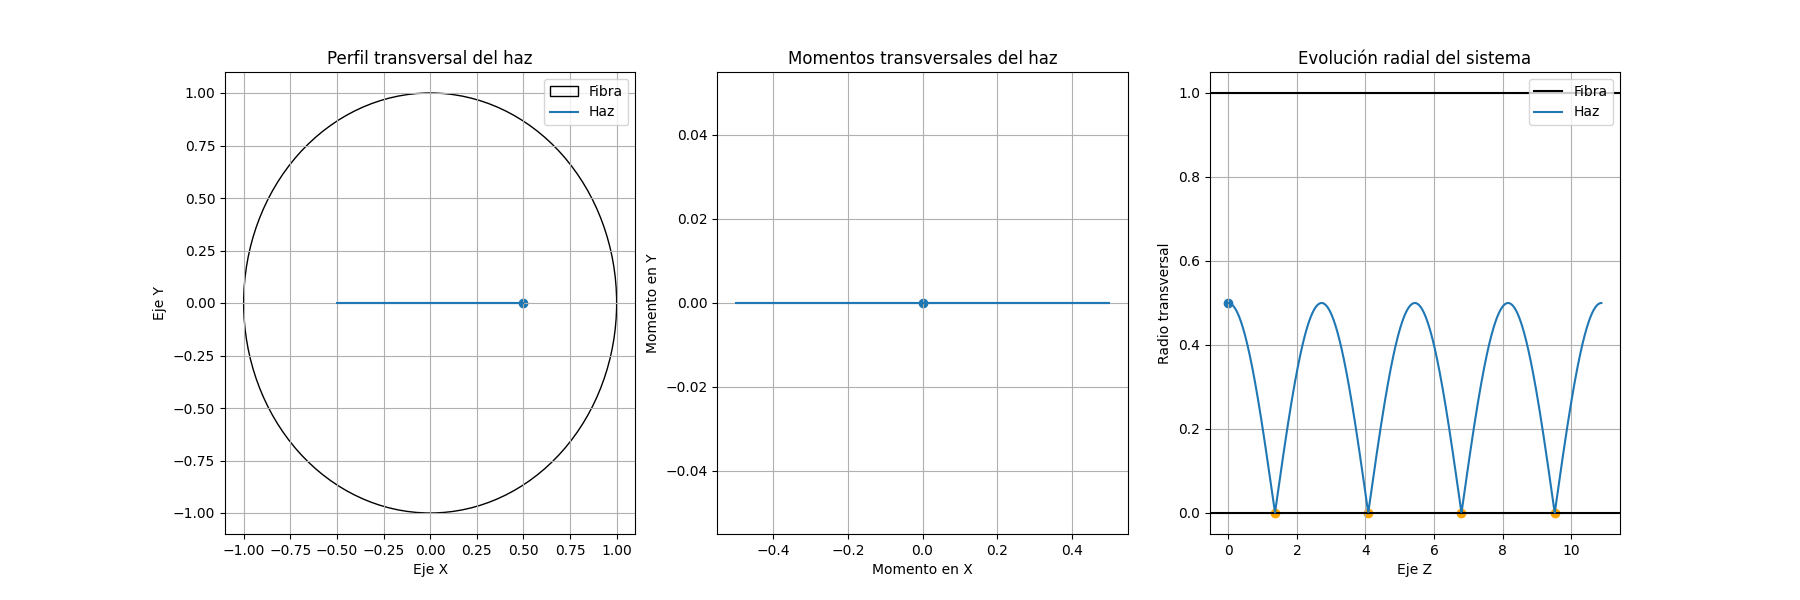

In [3]:
x0, y0, px0, py0 = 0.5, 0.0, 0.0, 0.0
x, y, z = Graficar2D(x0, y0, px0, py0, focus = True)

Se observa claramente que el haz está limitado a moverse a modo de línea recta en el eje transversal a la fibra óptica. Los momentos también varían y son paralelos a las posiciones, lo que muestra que ciertamente este escenario supone que el momento angular $L_{z}$ es nulo. Nótese que para este escenario ocurren enfoques sucesivos los cuales están determinados por la expresión (en la forma adimensional):

$$\tilde{z} = \frac{(2n + 1)\pi}{2}\tilde{\gamma},$$

representado por los puntos naranja que se ven en la gráfica de la evolución radial del sistema. Por otro lado, la propagación en el espacio de este sistema puede verse a través de la siguiente representación:

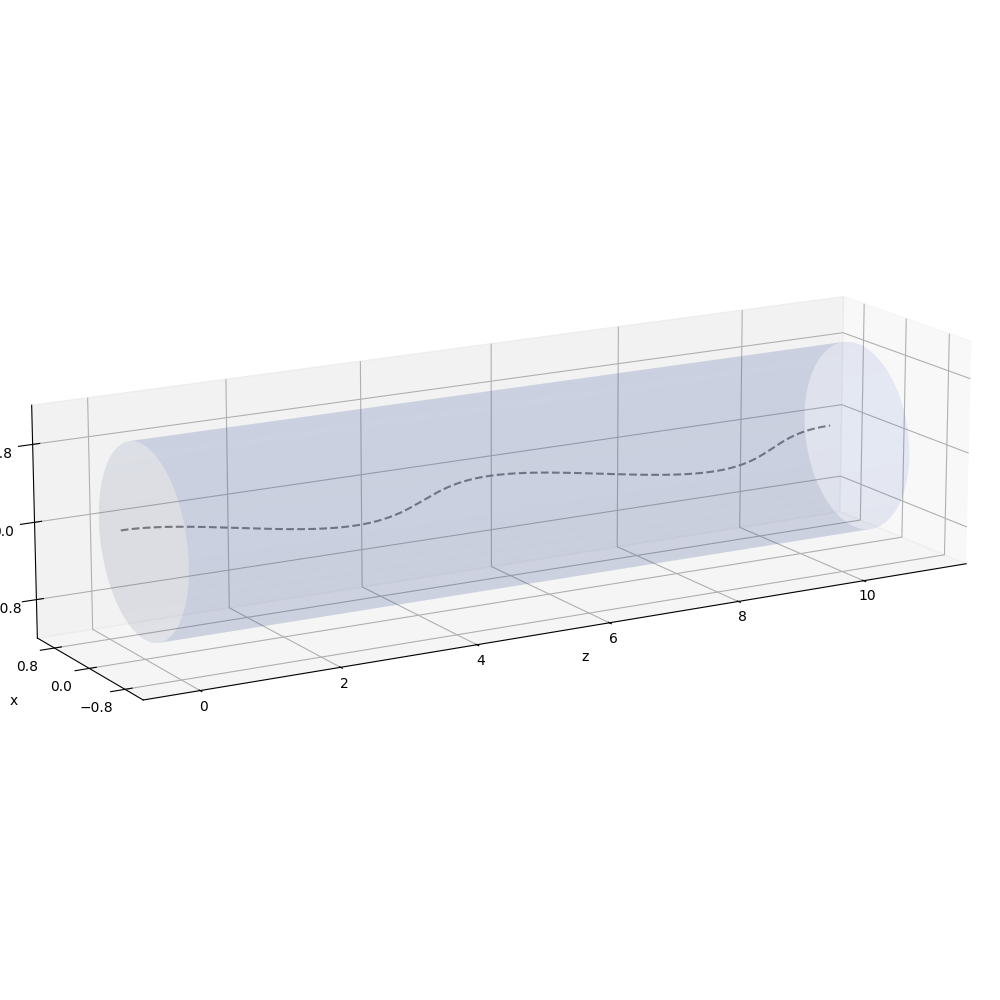

In [4]:
Graficar3D(x, y, z)

El haz muestra un comportamiento sinusoidal a lo largo de la fibra, tal y como esperaríamos de las ecuaciones de movimiento. Otro caso a considerar sería en el que la posición de entrada en la fibra no está sólo en uno de los ejes del sistema, sino "inclinado". Para ello consideresen las siguientes condiciones iniciales:

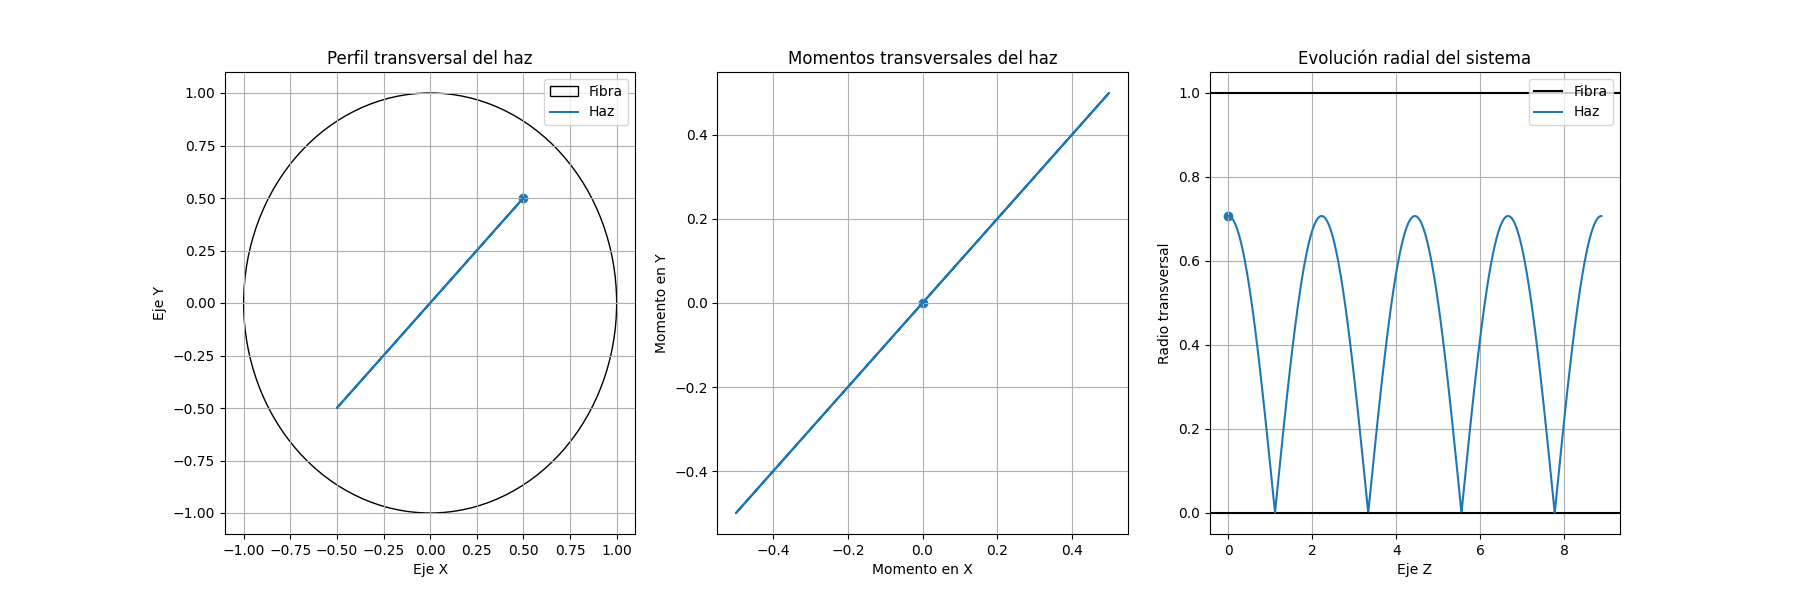

In [5]:
x0, y0, px0, py0 = 0.5, 0.5, 0.0, 0.0
x, y, z = Graficar2D(x0, y0, px0, py0)

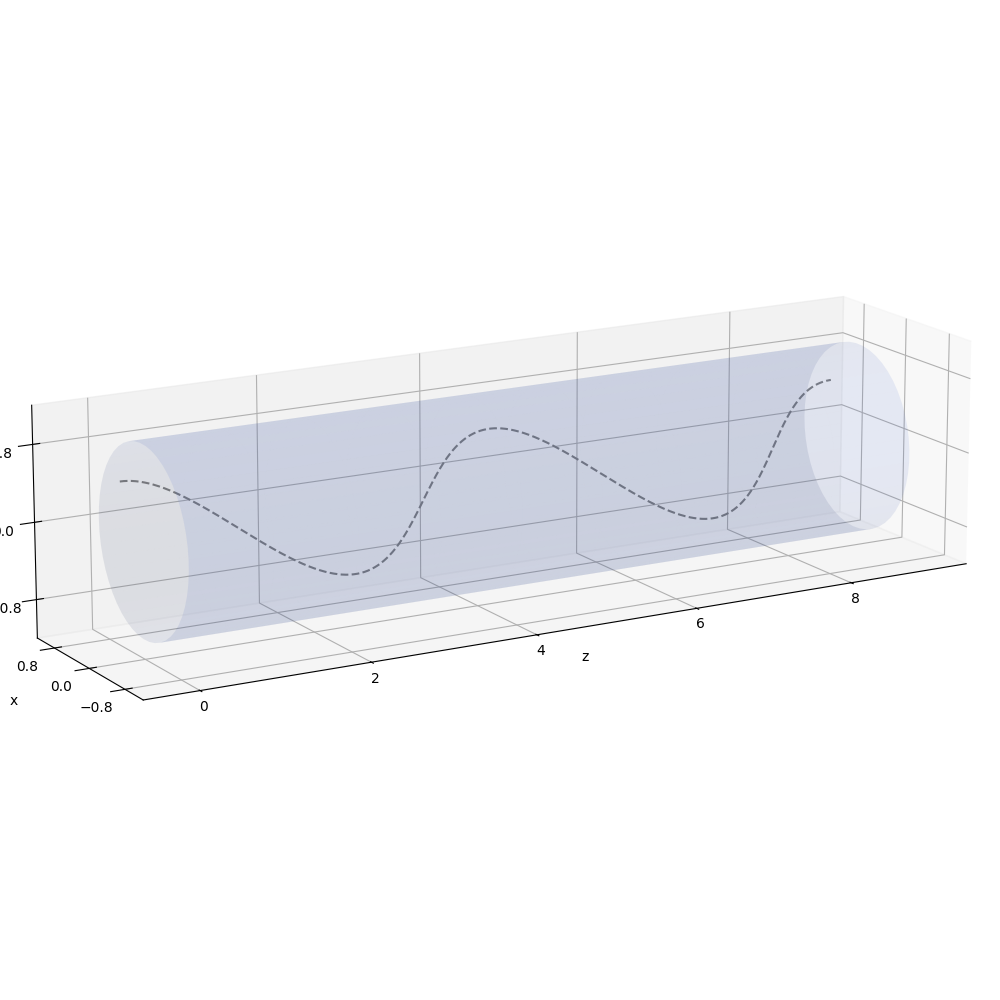

In [6]:
Graficar3D(x, y, z)

> **Caso #2: Rayo incidente con momento angular no nulo**

Este segundo caso introduce cambios en el sistema que ya no son tan sencillos como una trayectoria totalmente lineal. Al introducir momento angular, el sistema empieza a rotar en el plano transversal, lo que genera una especie de hélices en su trayectoria general. La solución general de la proyección de las trayectorias en el eje transversal muestra una elipse rotada la cual mantiene el radio del haz confinado entre dos radios, los cuales corresponden al valor del semi-eje mayor y menor de la elipse.

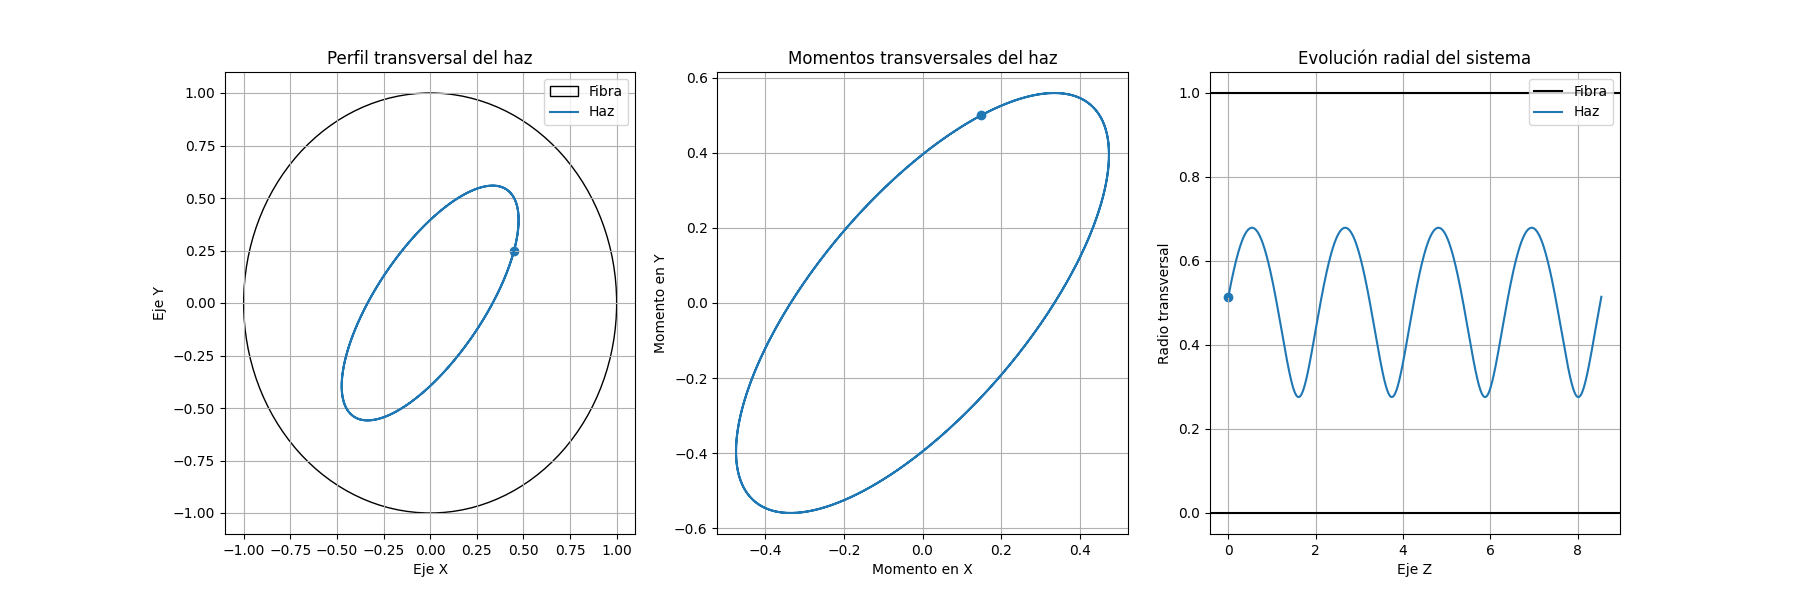

In [7]:
x0, y0, px0, py0 = 0.45, 0.25, 0.15, 0.5
x, y, z = Graficar2D(x0, y0, px0, py0)

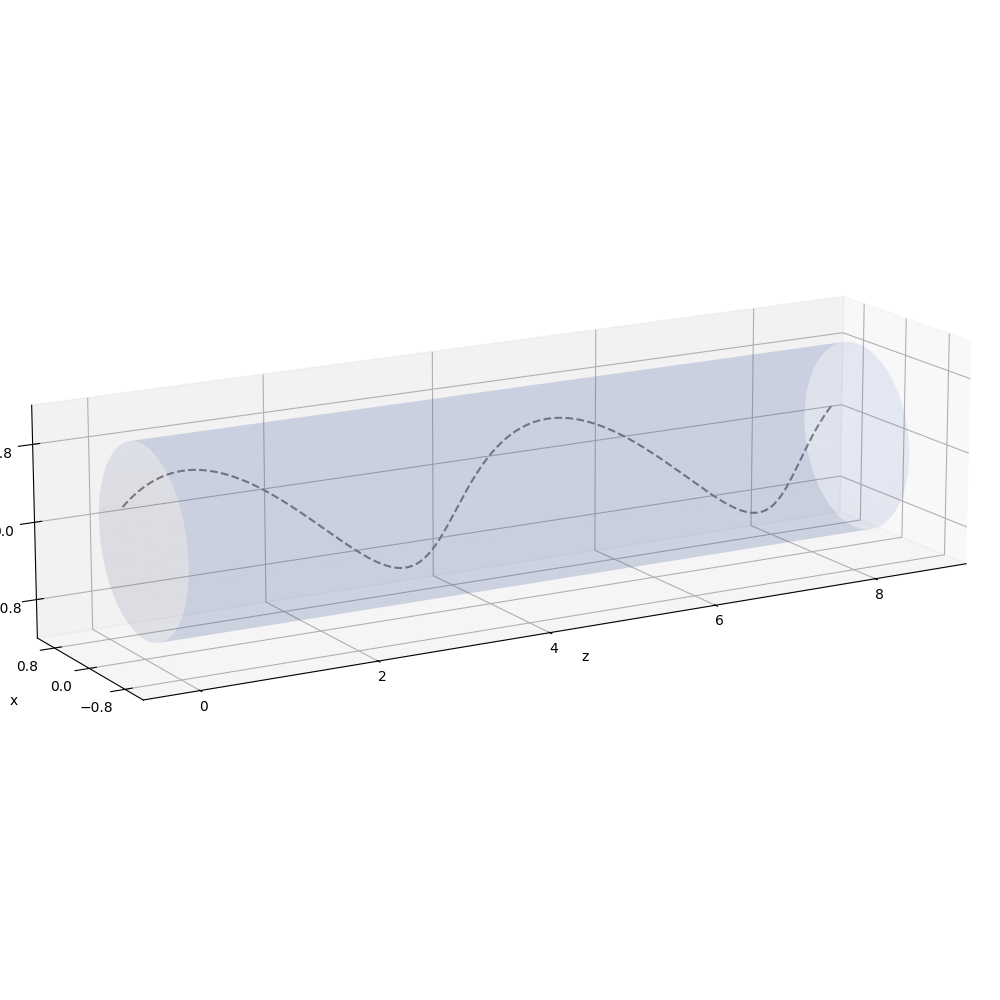

In [8]:
Graficar3D(x, y, z)

> **Caso #3: Rayo incidente en un punto fijo del sistema**

Este caso es muy interesante porque hace que las curvas del sistema sean totalmente circulares, trazando en el espacio tridimensional hélice de radio constante. La forma en la que se formulan las condiciones iniciales parte del hecho de que la energía del sistema es una constante de movimiento la cual se puede escribir como (en el sistema adimensional):

$$\tilde{\gamma}^{2} = 1 - \tilde{\rho}^{2} - \tilde{p_\rho}^{2} - \frac{\tilde{L}_{z}^{2}}{\tilde{\rho}^{2}}$$

Para un punto fijo se requiere que el valor del momento radial sea nulo, lo que hace que la energía del sistema sea igual al valor de un potencial efectivo (haciéndo el puente con lo que sucede en otros sistemas físicos). Es decir:

$$-\tilde{\gamma} = -\sqrt{1 - \tilde{\rho}^{2} - \frac{\tilde{L}_{z}^{2}}{\tilde{\rho}^{2}}} = \tilde{H}(\tilde{x}, \tilde{y}, p_{\tilde{x}}, p_{\tilde{y}}) = V_{eff}(\tilde{\rho})
$$

Ahora bien, también al considerar un punto fijo se debe de cumplir que no haya cambio en el momento radial, esto es, por las ecuaciones de Hamilton:

$$\dot{p}_{\tilde{\rho}} = -\frac{\partial{\tilde{H}}}{\partial{\tilde{\rho}}} = -\frac{\partial{V_{eff}(\tilde{\rho})}}{\partial{\tilde{\rho}}} = -\frac{1}{\tilde{\gamma}}\left(2\tilde{\rho} - \frac{2\tilde{L}_{z}^{2}}{\tilde{\rho}^{3}}\right) = 0$$
$$\tilde{\rho}_{fijo} = \sqrt{|\tilde{L}_{z}|}$$

Lo que se traduce, en condiciones iniciales:

$$\tilde{\rho}_{fijo} = \sqrt{|\tilde{x}_{0}p_{\tilde{y}0} - \tilde{y}_{0}p_{\tilde{x}0}|} = \sqrt{\tilde{x}_{0}^{2} + \tilde{y}_{0}^{2}}$$

Una cosa fácil que se puede hacer es hacer $q_{i} = p_{q_{j}} = a \neq 0$ y $q_{j} = p_{q_{i}} = 0$ para $i \neq j$. De esta manera se generan trayectorias de la forma:

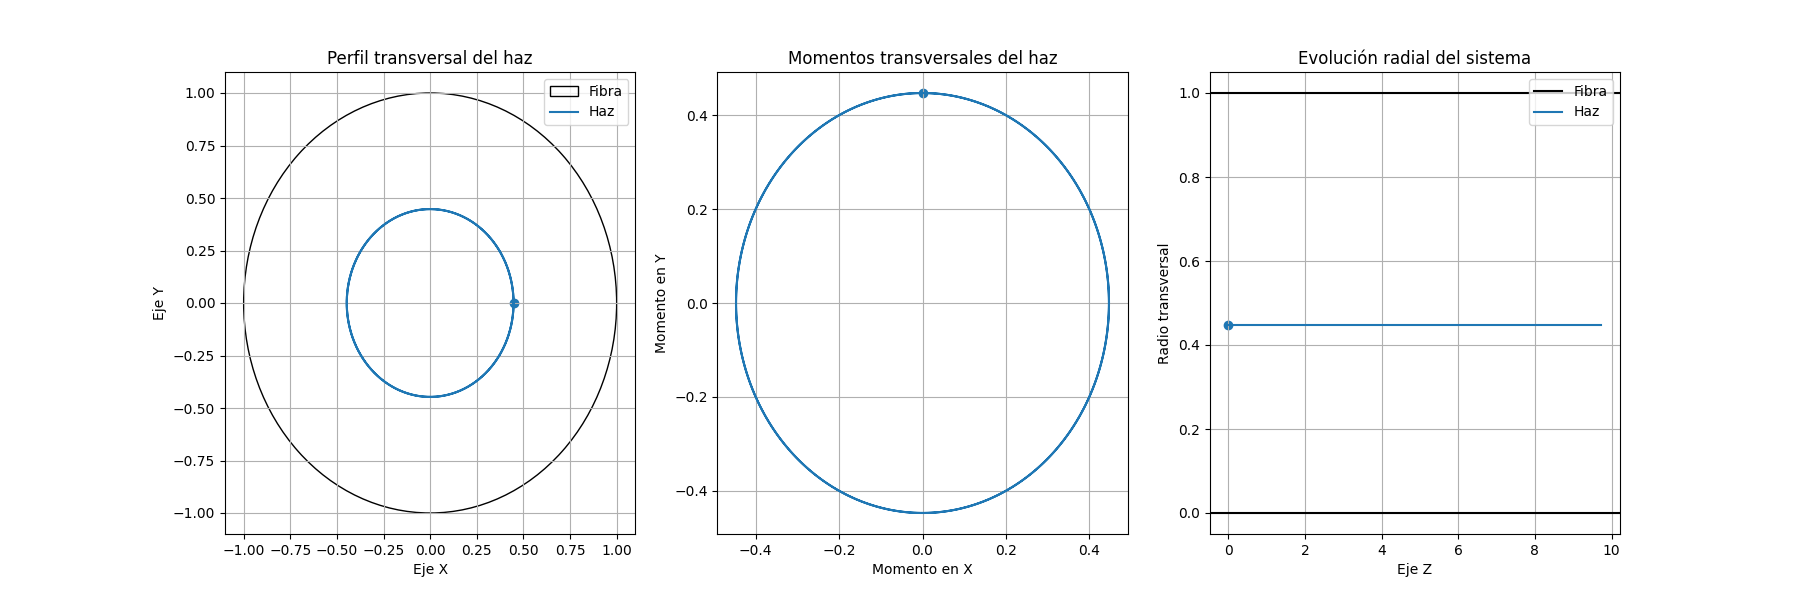

In [9]:
x0, y0, px0, py0 = 0.4472, 0.0, 0.0, 0.4472
x, y, z = Graficar2D(x0, y0, px0, py0)

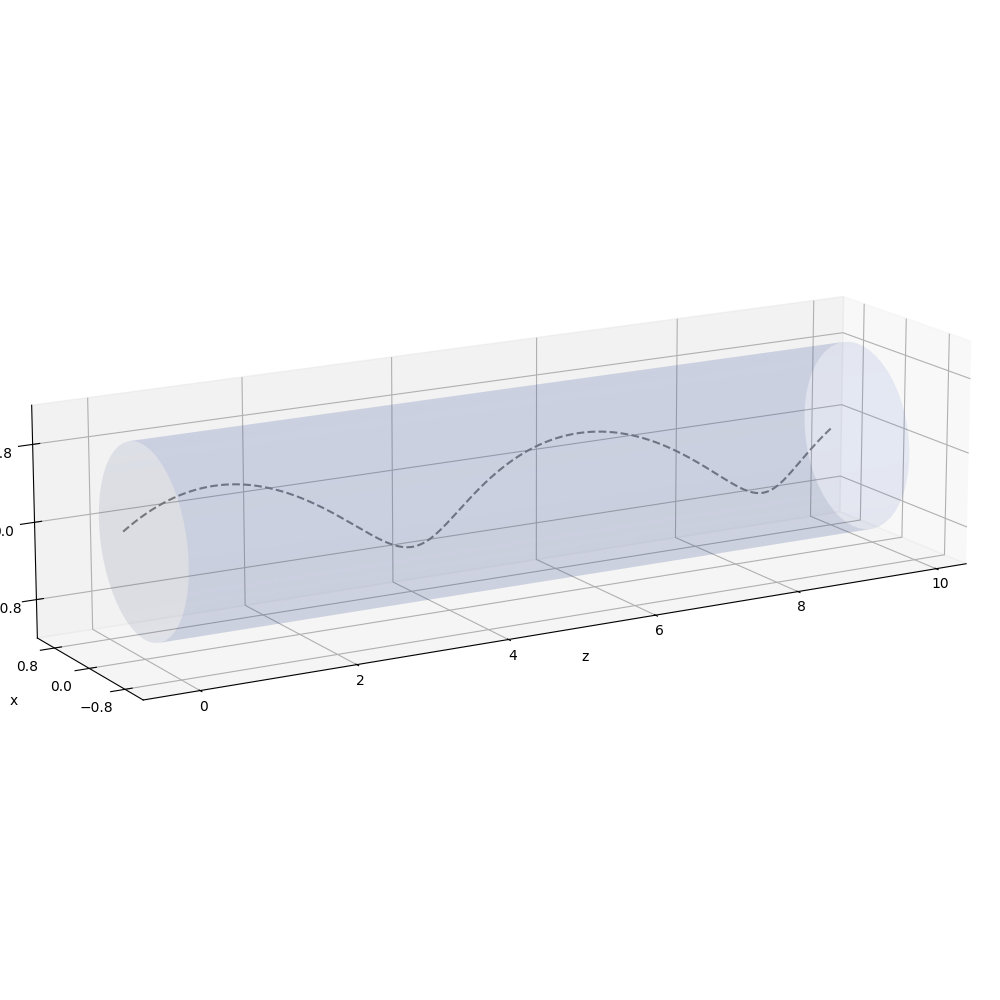

In [10]:
Graficar3D(x, y, z)

> **Caso #4: Rayo incidente en un punto cercano a un punto fijo del sistema**

Si tomamos el caso anterior y lo analizamos para un valor de $\tilde{\rho} = \tilde{\rho}_{fijo} + \varepsilon$, el punto fijo empieza a mostrar oscilaciones más similares a las que tendríamos en un caso cualquiera de $\tilde{L}_{z} \neq 0$. En este caso, pese a la pequeña "perturbación", las trayectorias transversales mantienen una forma circular semi-deformada hacia una elipse. El resultado de la perturbación muestra que la pequeña variación hace que el radio oscile con $\tilde{\omega}_{rad} = 2\tilde{\omega}$, resultado que proviene de usar la ecuación de movimiento para $\ddot{\tilde{\rho}}$:

$$\ddot{\tilde{\rho}} = \ddot{\tilde{\rho}}_{fijo} + \ddot{\varepsilon} = -\left.\frac{1}{\tilde{\gamma}^{2}}\frac{\partial{V_{eff}(\tilde{\rho})}}{\partial{\tilde{\rho}}}\right|_{\tilde{rho} = \tilde{\rho}_{fijo} + \varepsilon} = -\tilde{\omega}^{2}(\tilde{\rho}_{fijo} + \varepsilon) - \frac{\tilde{L}_{z}^{2}}{(\tilde{\rho}_{fijo} + \varepsilon)^{3}} = -\tilde{\omega}^{2}\tilde{\rho}_{fijo} - \frac{\tilde{L}_{z}^{2}}{\tilde{\gamma}^{2}\tilde{\rho}_{fijo}^{3}}\left(1 + \frac{\varepsilon}{\tilde{\rho}_{fijo}}\right)^{-3} \approx -\tilde{\omega}^{2}\tilde{\rho}_{fijo} -\tilde{\omega}^{2}\varepsilon - \frac{\tilde{L}_{z}^{2}}{\tilde{\gamma}^{2}\tilde{\rho}_{fijo}^{3}} - \frac{3\tilde{L}_{z}^{2}}{\tilde{\gamma}^{2}\tilde{\rho}_{fijo}^{4}}\varepsilon$$

$$\ddot\varepsilon = -\left(\tilde{\omega}^{2} + 3\frac{\tilde{L}_{z}^{2}}{\tilde{\gamma}^{2}\tilde{\rho}_{fijo}^{4}}\right)\varepsilon = -\left(\tilde{\omega}^{2} + 3\frac{\tilde{L}_{z}^{2}}{\tilde{\gamma}^{2}\tilde{L}_{z}^{2}}\right)\varepsilon = -\left(\tilde{\omega}^{2} + \frac{3}{\tilde{\gamma}^{2}}\right)\varepsilon = -4\tilde{\omega}^{2}\varepsilon$$

Donde aparece inmediatamente la relación previamente comentada: $\tilde{\omega}_{rad} = 2\tilde{\omega}$. 

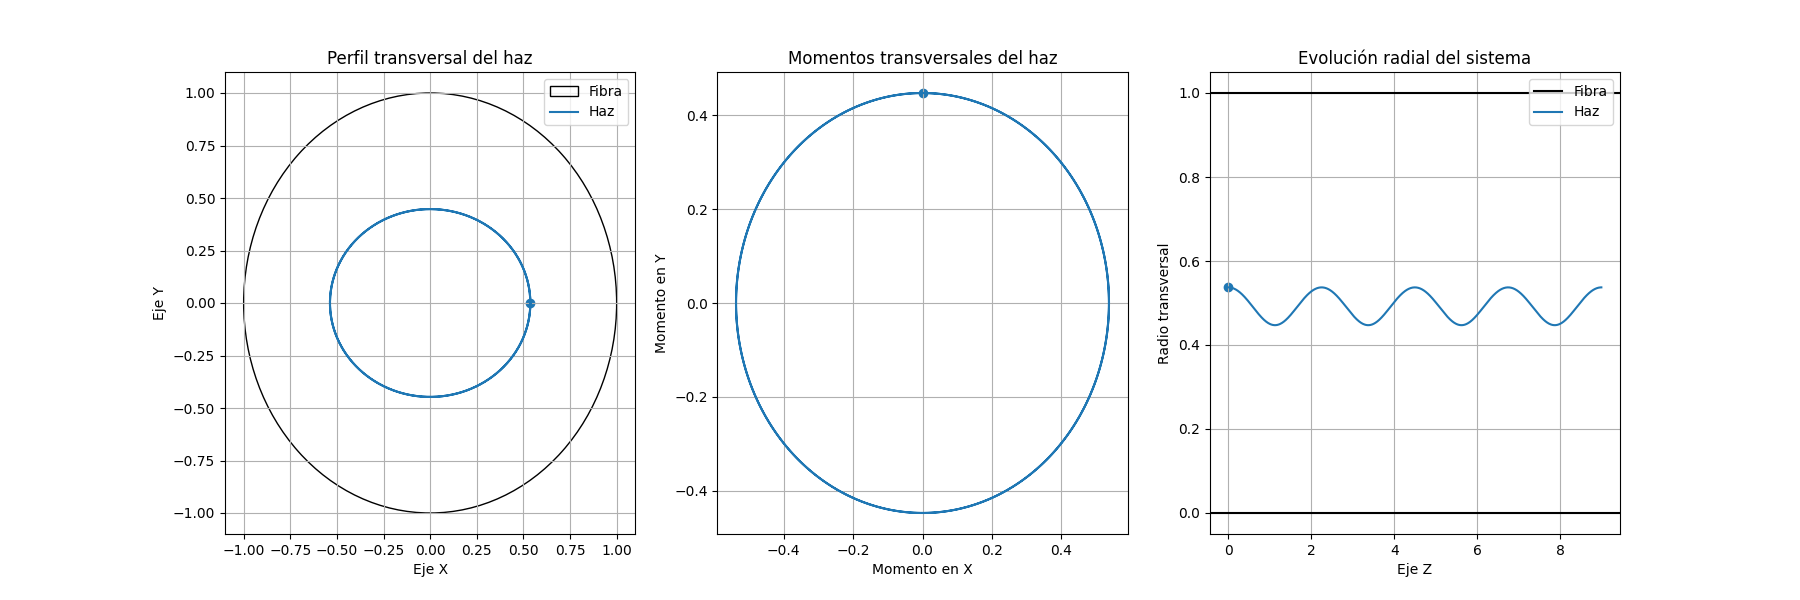

In [11]:
epsilon = 0.09
x0, y0, px0, py0 = 0.4472 + epsilon, 0.0, 0.0, 0.4472
x, y, z = Graficar2D(x0, y0, px0, py0)

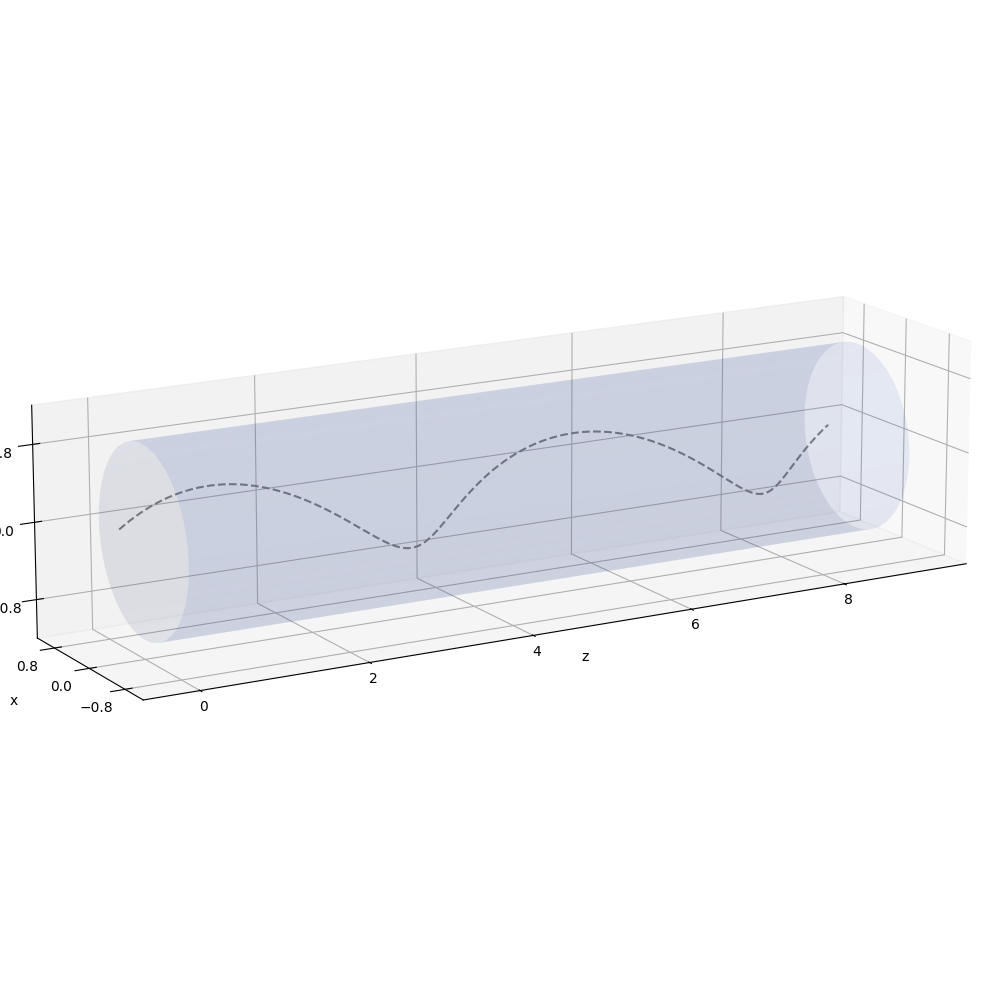

In [12]:
Graficar3D(x, y, z)

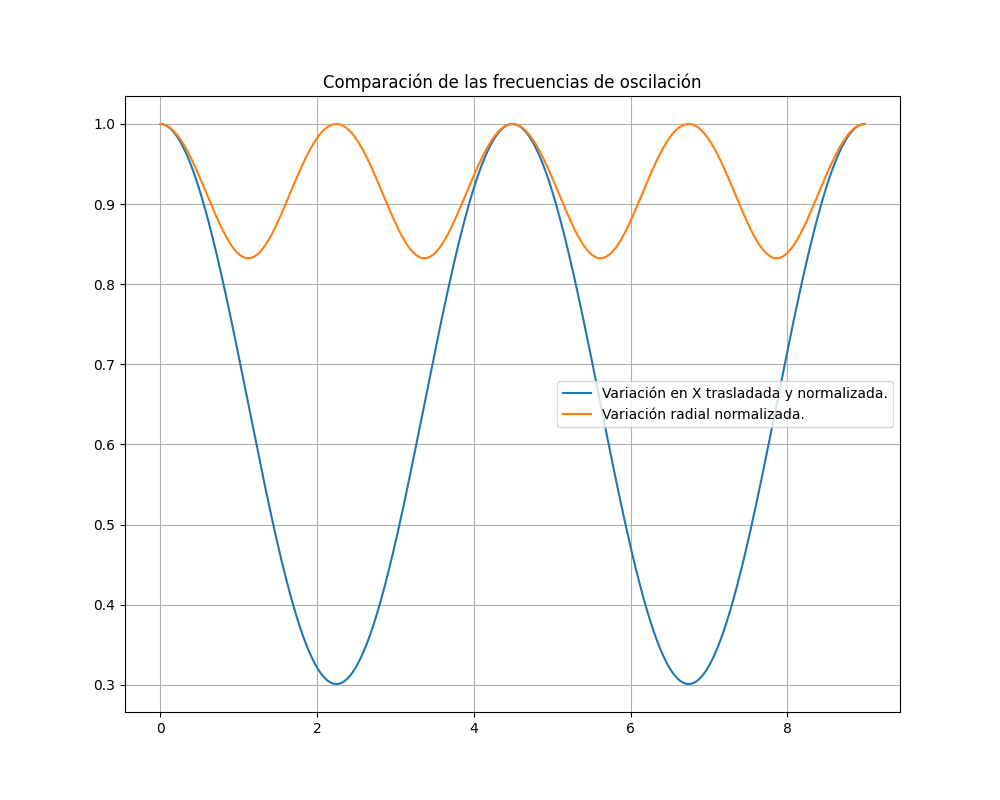

In [13]:
z, x, y, px, py, rho, prho = Trayectorias(x0, y0, px0, py0)
fig, ax = plt.subplots(figsize = (10, 8))
ax.plot(z, (x + 1)/np.max(x + 1), label = "Variación en X trasladada y normalizada.")
ax.plot(z, rho/np.max(rho), label = "Variación radial normalizada.")
ax.set_title("Comparación de las frecuencias de oscilación")
ax.grid()
ax.legend()

Como se logra apreciar, ciertamente la frecuencia angular de la variación radial coincide con el doble de la variación en la posición en x dado un intervalo de tiempo fijo. Comparando esto con lo que aparece en el caso 2 se tiene una enorme diferencia:

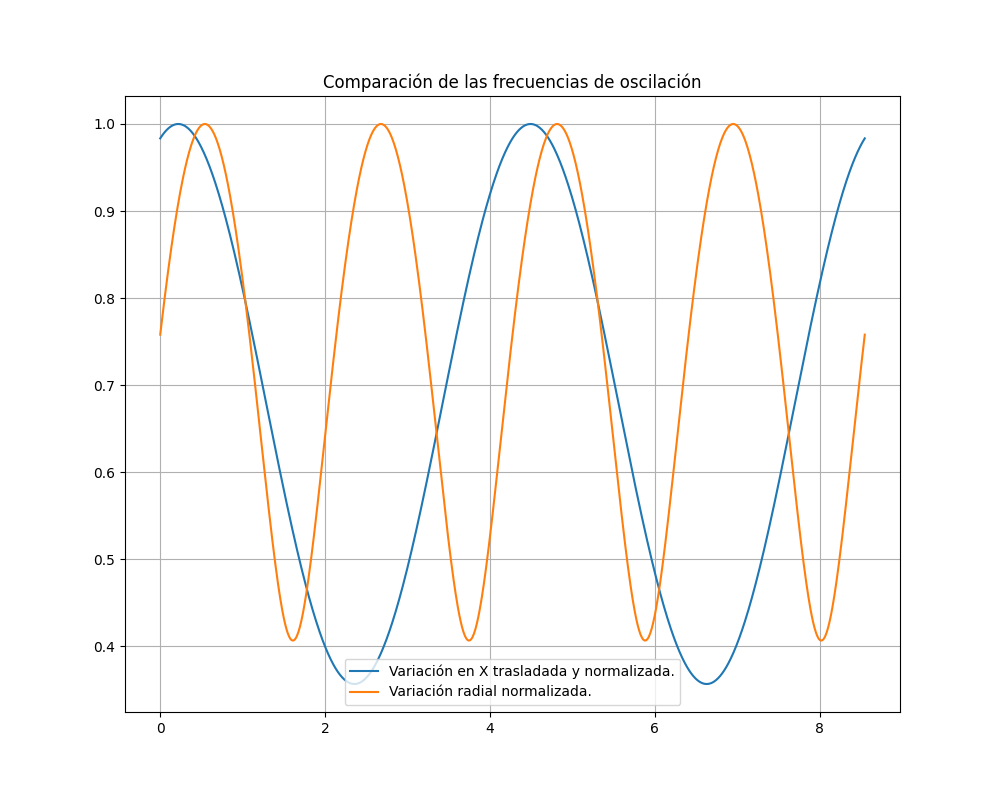

In [14]:
x0, y0, px0, py0 = 0.45, 0.25, 0.15, 0.5
z, x, y, px, py, rho, prho = Trayectorias(x0, y0, px0, py0)
fig, ax = plt.subplots(figsize = (10, 8))
ax.plot(z, (x + 1)/np.max(x + 1), label = "Variación en X trasladada y normalizada.")
ax.plot(z, rho/np.max(rho), label = "Variación radial normalizada.")
ax.set_title("Comparación de las frecuencias de oscilación")
ax.grid()
ax.legend()

Nótese que aquí está claro que la relación entre las frecuencias de oscilación radial y traslacional son totalmente diferentes a una simple relación de 1:2.